In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy
from collections import namedtuple

device='cuda' if torch.cuda.is_available() else 'cpu'

print(f"using device: {device}")
if device=='cuda':
  gpu_name=torch.cuda.get_device_name(0)

  total_memory=torch.cuda.get_device_properties(0).total_memory

  total_memory_gb=total_memory/(1024**3)

  print("GPU", gpu_name)
  print("Total memory VRAM: ", total_memory_gb)


using device: cuda
GPU NVIDIA RTX PRO 6000 Blackwell Server Edition
Total memory VRAM:  94.97076416015625


In [44]:
class ReLUConvBN(nn.Module):
  def __init__(self, C_in, C_out, kernel_size, stride, padding, affine):
    super().__init__()
    self.relu=nn.ReLU(inplace=False)
    self.conv=nn.Conv2d(C_in, C_out, kernel_size, stride, padding, bias=False)
    self.bn=nn.BatchNorm2d(C_out, affine=affine)
  def forward(self, x):
    x=self.relu(x)
    x=self.conv(x)
    x=self.bn(x)
    return x



class SepConv(nn.Module):
  def __init__(self, C_in, C_out, kernel_size, stride, padding, affine):
    super().__init__()
    self.relu=nn.ReLU(inplace=False)
    self.conv_depthwise=nn.Conv2d(C_in, C_in, kernel_size, stride, padding, groups=C_in, bias=False)
    self.conv_pointwise=nn.Conv2d(C_in, C_out, kernel_size=1, bias=False)
    self.bn=nn.BatchNorm2d(C_out, affine=affine)
    self.relu2=nn.ReLU(inplace=False)
    self.conv2_depthwise=nn.Conv2d(C_out, C_out, kernel_size, stride=1, padding=padding, groups=C_out, bias=False)
    self.conv2_pointwise=nn.Conv2d(C_out, C_out, kernel_size=1, bias=False)
    self.bn2=nn.BatchNorm2d(C_out, affine=affine)
  def forward(self, x):
    x=self.relu(x)
    x=self.conv_depthwise(x)
    x=self.conv_pointwise(x)
    x=self.bn(x)
    x=self.relu2(x)
    x=self.conv2_depthwise(x)
    x=self.conv2_pointwise(x)
    x=self.bn2(x)
    return x



class DilConv(nn.Module):
  def __init__(self, C_in, C_out, kernel_size, stride, padding, dilation, affine):
    super().__init__()
    self.relu=nn.ReLU(inplace=False)
    self.conv_depthwise=nn.Conv2d(C_in, C_in, kernel_size, stride=stride, padding=padding, dilation=dilation, groups=C_in, bias=False)
    self.conv_pointwise=nn.Conv2d(C_in, C_out, kernel_size=1, bias=False)
    self.bn=nn.BatchNorm2d(C_out, affine=affine)
  def forward(self, x):
    x=self.relu(x)
    x=self.conv_depthwise(x)
    x=self.conv_pointwise(x)
    x=self.bn(x)
    return x

class Identity(nn.Module):
  def __init__(self):
    super().__init__()
  def forward(self, x):
    return x

class Zero(nn.Module):
  def __init__(self, stride):
    super().__init__()
    self.stride=stride
  def forward(self, x):
    x=x[:, :, ::self.stride, ::self.stride]
    x=x*0
    return x

class FactorizedReduce(nn.Module):
  def __init__(self, C_in, C_out, affine=True):
    super().__init__()
    self.relu=nn.ReLU(inplace=False)
    self.conv_1_by_1=nn.Conv2d(C_in, C_out//2, kernel_size=1, stride=2,  bias=False)
    self.conv_1_by_1_2=nn.Conv2d(C_in, C_out//2, kernel_size=1, stride=2,  bias=False)
    self.bn=nn.BatchNorm2d(C_out, affine=affine)
  def forward(self, x):
    x=self.relu(x)
    x_new_1=self.conv_1_by_1(x)
    x_new_2=self.conv_1_by_1_2(x[:, :, 1:, 1:])
    x_resultant=torch.cat([x_new_1, x_new_2], 1)
    x_resultant=self.bn(x_resultant)
    return x_resultant

In [45]:
OPS={
    'none': lambda C, stride, affine: Zero(stride),
    'avg_pool_3x3': lambda C, stride, affine: nn.Sequential(nn.AvgPool2d(3, stride=stride, padding=1, count_include_pad=False), nn.BatchNorm2d(C, affine=affine)),
    'max_pool_3x3': lambda C, stride, affine: nn.Sequential(nn.MaxPool2d(3, stride=stride, padding=1), nn.BatchNorm2d(C, affine=affine)),
    'skip_connect': lambda C, stride, affine: Identity() if stride==1 else FactorizedReduce(C, C, affine=affine),
    'sep_conv_3x3': lambda C, stride, affine: SepConv(C, C, 3, stride, 1, affine),
    'sep_conv_5x5': lambda C, stride, affine: SepConv(C, C, 5, stride, 2, affine),
    'dil_conv_3x3': lambda C, stride, affine: DilConv(C, C, 3, stride, 2, 2, affine),
    'dil_conv_5x5': lambda C, stride, affine: DilConv(C, C, 5, stride, 4, 2, affine),
}

In [46]:
x=torch.randn(2, 16, 32, 32)
for key in OPS.keys():
  op = OPS[key](C=16, stride=1, affine=True)
  x_resultant=op(x)
  print(key, x_resultant.shape)
for key in OPS.keys():
  op=OPS[key](C=16, stride=2, affine=True)
  x_resultant=op(x)
  print(key, x_resultant.shape)

none torch.Size([2, 16, 32, 32])
avg_pool_3x3 torch.Size([2, 16, 32, 32])
max_pool_3x3 torch.Size([2, 16, 32, 32])
skip_connect torch.Size([2, 16, 32, 32])
sep_conv_3x3 torch.Size([2, 16, 32, 32])
sep_conv_5x5 torch.Size([2, 16, 32, 32])
dil_conv_3x3 torch.Size([2, 16, 32, 32])
dil_conv_5x5 torch.Size([2, 16, 32, 32])
none torch.Size([2, 16, 16, 16])
avg_pool_3x3 torch.Size([2, 16, 16, 16])
max_pool_3x3 torch.Size([2, 16, 16, 16])
skip_connect torch.Size([2, 16, 16, 16])
sep_conv_3x3 torch.Size([2, 16, 16, 16])
sep_conv_5x5 torch.Size([2, 16, 16, 16])
dil_conv_3x3 torch.Size([2, 16, 16, 16])
dil_conv_5x5 torch.Size([2, 16, 16, 16])


In [47]:
class MixedOp(nn.Module):
  def __init__(self, C, stride):
    super().__init__()
    self.ops=nn.ModuleList()
    for primitive in OPS.keys():
      op=OPS[primitive](C, stride, affine=False)
      self.ops.append(op)
  def forward(self, x, weights):
    weighted_sum=sum(w*op(x) for w, op in zip(weights, self.ops))
    return weighted_sum

In [48]:
instance=MixedOp(C=16, stride=1)
random_weights = torch.randn(8, requires_grad=True)
softmax_weights = F.softmax(random_weights, dim=0)
forward_pass = instance(x, softmax_weights)
forward_pass.sum().backward()
print(softmax_weights)
print(forward_pass.shape)
print(random_weights.grad)

tensor([0.1576, 0.0769, 0.0305, 0.1759, 0.2129, 0.2265, 0.0978, 0.0218],
       grad_fn=<SoftmaxBackward0>)
torch.Size([2, 16, 32, 32])
tensor([-6.3002, -3.0731, -1.2203, 32.9406, -8.5093, -9.0558, -3.9091, -0.8727])


In [49]:
class Cell(nn.Module):
  def __init__(self,  steps, C_prev, C_prev_prev, C, reduction, reduction_prev):
    super().__init__()
    #self.s0=s0
    #self.s1=s1
    self.reduction=reduction
    if reduction_prev:
      self.preprocess_conv2d=FactorizedReduce(C_prev_prev, C, affine=False)
    else:
      self.preprocess_conv2d=ReLUConvBN(C_prev_prev, C, 1, 1, 0, affine=False)
    self.preprocess_conv2d_2=ReLUConvBN(C_prev, C, 1, 1, 0, affine=False)
    self.steps=steps
    self.edges=nn.ModuleList()
    #2 + 3 + 4 + 5 -> 14
    for i in range(steps):
      for j in range(i+2):
        stride=2 if reduction and j<2 else 1
        op=MixedOp(C, stride)
        self.edges.append(op)
    #each intermediate node receives input from previous one via MixedOp

    #reduction cells use stride=2 on edges connected to inputs s1,s0 everywhere else it is stride=1

    #output is torch.cat of all previous 4 intermediate nodes along channel dim

  def forward(self, x_s0, x_s1, weights):
    x_s0=self.preprocess_conv2d(x_s0)
    x_s1=self.preprocess_conv2d_2(x_s1)
    states=[x_s0, x_s1]
    offset=0
    for i in range(self.steps):
      s=sum(
          self.edges[offset + j](states[j], weights[offset + j])
            for j in range(len(states))
      )
      offset+=len(states)
      states.append(s)
    #node 2 -> node 3 -> node 4 -> node 5
    return torch.cat(states[2:], dim=1)


In [50]:
s0 = torch.randn(2, 48, 32, 32)
s1 = torch.randn(2, 48, 32, 32)

weights = F.softmax(torch.randn(14, 8), dim=-1)

cell_normal=Cell( 4, 48, 48, 16, False, False)
cell_reduce=Cell( 4,  48, 48, 16, True, False)

cell_normal_out=cell_normal(s0, s1, weights)
cell_reduce_out=cell_reduce(s0, s1, weights)

print(cell_normal_out.shape)
print(cell_reduce_out.shape)

torch.Size([2, 64, 32, 32])
torch.Size([2, 64, 16, 16])


In [51]:
class Search_Network(nn.Module):
  def __init__(self, C_init, num_classes,  total_cells=8, steps=4):
    super().__init__()
    C_current=C_init
    C_prev=C_init*3
    C_prev_prev=C_init*3
    reduction_prev=False
    self.stem=nn.Sequential(nn.Conv2d(3, C_init*3, 3, padding=1, bias=False), nn.BatchNorm2d(C_init*3))
    self.cells=nn.ModuleList()
    for i in range(total_cells):
      reduction= (i==total_cells//3 or i==2*total_cells//3)
      cell=Cell(steps, C_prev, C_prev_prev, C_current, reduction, reduction_prev)
      self.cells.append(cell)
      C_prev_prev=C_prev
      C_prev=C_current*4
      if reduction:
        C_current*=2
      reduction_prev=reduction

    self.alpha_normal=nn.Parameter(torch.randn(14,8))
    self.alpha_reduce=nn.Parameter(torch.randn(14,8))
    self.global_pooling=nn.AdaptiveAvgPool2d(1)
    self.classifier=nn.Linear(C_prev, num_classes)
  def arch_parameters(self):
    return self.alpha_normal, self.alpha_reduce
  def forward(self, x):
    weights_normal=F.softmax(self.alpha_normal, dim=-1)
    weights_reduce=F.softmax(self.alpha_reduce, dim=-1)
    s1=s0=self.stem(x)
    for cell in self.cells:
      if cell.reduction:
        s0, s1=s1, cell(s0, s1, weights_reduce)
      else:
        s0, s1=s1, cell(s0, s1, weights_normal)
    s1=self.global_pooling(s1)
    s1=s1.view(s1.size(0), -1)
    logits=self.classifier(s1)
    return logits

In [52]:
model = Search_Network(C_init=16, num_classes=10)
x = torch.randn(4, 3, 32, 32)
logits = model(x)
print(logits.shape)

# count parameters
total_params = sum(p.numel() for p in model.parameters())
arch_params = sum(p.numel() for p in model.arch_parameters())
weight_params = total_params - arch_params

print(f"Total params: {total_params}")
print(f"Arch params: {arch_params}")
print(f"Weight params: {weight_params}")

torch.Size([4, 10])
Total params: 1478298
Arch params: 224
Weight params: 1478074


In [53]:
class Architect_first_order:
  def __init__(self, model, arch_lr, arch_weight_decay):
    super().__init__()
    self.model=model
    self.optimizer=torch.optim.Adam(self.model.arch_parameters(), lr=arch_lr, weight_decay=arch_weight_decay)
  def step(self, x_val, y_val):
    self.optimizer.zero_grad()
    logits=self.model(x_val)
    loss=F.cross_entropy(logits, y_val)
    loss.backward()
    self.optimizer.step()


In [54]:
model = Search_Network(C_init=16, num_classes=10)
architect = Architect_first_order(model, arch_lr=3e-4, arch_weight_decay=1e-3)

x_val = torch.randn(4, 3, 32, 32)
y_val = torch.randint(0, 10, (4,))

alpha_before = model.alpha_normal.clone()
architect.step(x_val, y_val)
alpha_after = model.alpha_normal.clone()

print(torch.allclose(alpha_before, alpha_after))  # should print False

False


In [55]:
class Architect_second_order(Architect_first_order):
  def step(self, x_val, y_val, x_train, y_train, xi):
    self.optimizer.zero_grad()
    arch_params = set(self.model.arch_parameters())
    w = [p for p in self.model.parameters() if p not in arch_params]

    logits_train=self.model(x_train)
    train_loss=F.cross_entropy(logits_train, y_train)
    #w=list(self.model.parameters())
    dw=torch.autograd.grad(train_loss, w)
    w_prime=[p - xi*d for p, d in zip(w, dw)]

    original_weights=[p.data.clone() for p in self.model.parameters()]

    for p, p_prime in zip(w, w_prime):
      p.data=p.data.copy_(p_prime)

    logits_val=self.model(x_val)
    val_loss=F.cross_entropy(logits_val, y_val)



    d_w_prime = torch.autograd.grad(val_loss, w, retain_graph=True)
    d_alpha=torch.autograd.grad(val_loss, self.model.arch_parameters())

    for p, p_original in zip(self.model.parameters(), original_weights):
      p.data.copy_(p_original)

    epsilon=0.01/torch.cat([g.flatten() for g in d_w_prime]).norm()

    w_plus  = [p + epsilon * g for p, g in zip(w, d_w_prime)]
    w_minus = [p - epsilon * g for p, g in zip(w, d_w_prime)]

    for p, p_w_plus in zip(w, w_plus):
      p.data.copy_(p_w_plus)

    logits_plus=self.model(x_train)
    plus_loss=F.cross_entropy(logits_plus, y_train)
    grad_alpha_plus=torch.autograd.grad(plus_loss, self.model.arch_parameters())

    for p, p_original in zip(self.model.parameters(), original_weights):
      p.data.copy_(p_original)

    for p, p_w_minus in zip(w, w_minus):
      p.data.copy_(p_w_minus)

    logits_minus=self.model(x_train)
    minus_loss=F.cross_entropy(logits_minus, y_train)
    grad_alpha_minus=torch.autograd.grad(minus_loss, self.model.arch_parameters())

    for p, p_original in zip(self.model.parameters(), original_weights):
      p.data.copy_(p_original)

    correction_term=[(g_plus-g_minus)/(2*epsilon) for g_plus, g_minus in zip(grad_alpha_plus, grad_alpha_minus)]

    final_grad=[dv - xi*c for dv, c in zip(d_alpha, correction_term)]

    for param, grad in zip(self.model.arch_parameters(), final_grad):
      param.grad=grad
    self.optimizer.step()

In [56]:
model = Search_Network(C_init=16, num_classes=10)
architect = Architect_second_order(model, arch_lr=3e-4, arch_weight_decay=1e-3)

x_train = torch.randn(4, 3, 32, 32)
y_train = torch.randint(0, 10, (4,))
x_val = torch.randn(4, 3, 32, 32)
y_val = torch.randint(0, 10, (4,))

alpha_before = model.alpha_normal.clone()
architect.step(x_val, y_val, x_train, y_train, xi=0.01)
alpha_after = model.alpha_normal.clone()

print(torch.allclose(alpha_before, alpha_after))  # should print False

False


In [57]:
import torchvision
import torchvision.transforms as transforms

CIFAR_MEAN = [0.49139968, 0.48215827, 0.44653124]
CIFAR_STD  = [0.24703233, 0.24348505, 0.26158768]

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

from torch.utils.data import random_split

full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform
)

n = len(full_train)  # 50000
train_data, val_data = random_split(full_train, [n//2, n//2])

val_data.dataset.transform = val_transform

train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    pin_memory=True,
    num_workers=0
)

val_loader = torch.utils.data.DataLoader(
    val_data,
    batch_size=64,
    shuffle=True,
    pin_memory=True,
    num_workers=0
)



In [ ]:
import os
os.makedirs('checkpoints', exist_ok=True)
model=Search_Network(C_init=16, num_classes=10).to(device)
architect=Architect_second_order(model, arch_lr=3e-4, arch_weight_decay=1e-3)
weight_params = [p for p in model.parameters() if p not in set(model.arch_parameters())]
optimizer=torch.optim.SGD(weight_params, lr=0.025, momentum=0.9, weight_decay=3e-4)
cosine_scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,  T_max=50, eta_min=0)

for epoch in range(50):
  total_loss=0
  count=0

  for (batch_val, label_val), (batch_train, label_train) in zip(val_loader, train_loader):
    batch_train = batch_train.to(device)
    label_train = label_train.to(device)
    batch_val   = batch_val.to(device)
    label_val   = label_val.to(device)

    train_result=model(batch_train)
    loss=F.cross_entropy(train_result, label_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    architect.step(batch_val, label_val, batch_train, label_train, xi=0.025)
    total_loss+=loss.item()
    count+=1
  avg_loss=total_loss/count
  cosine_scheduler.step()
  print(f"Epoch {epoch} | Loss {loss.item():.4f}")

  if(epoch+1)%5==0:
    torch.save({
        'epoch':epoch,
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict(),
        'scheduler_state_dict':cosine_scheduler.state_dict(),
        'arch_normal': model.alpha_normal.data,
        'arch_reduce': model.alpha_reduce.data,
        'avg_loss': avg_loss,
    }, f'checkpoints/search_epoch_{epoch}.pt')
    print(f"checkpoint saved at epoch {epoch}")

Epoch 0 | Loss 1.4297
Epoch 1 | Loss 1.2281
Epoch 2 | Loss 0.7021
Epoch 3 | Loss 0.5647
Epoch 4 | Loss 0.3987
checkpoint saved at epoch 4
Epoch 5 | Loss 0.5514
Epoch 6 | Loss 0.3480
Epoch 7 | Loss 0.3749
Epoch 8 | Loss 0.4157
Epoch 9 | Loss 0.4139
checkpoint saved at epoch 9
Epoch 10 | Loss 0.3304
Epoch 11 | Loss 0.1073
Epoch 12 | Loss 0.2221
Epoch 13 | Loss 0.2415
Epoch 14 | Loss 0.1913
checkpoint saved at epoch 14
Epoch 15 | Loss 0.2311
Epoch 16 | Loss 0.2374
Epoch 17 | Loss 0.0284
Epoch 18 | Loss 0.1727
Epoch 19 | Loss 0.0497
checkpoint saved at epoch 19
Epoch 20 | Loss 0.2947
Epoch 21 | Loss 0.0307
Epoch 22 | Loss 0.0381
Epoch 23 | Loss 0.0736
Epoch 24 | Loss 0.0080
checkpoint saved at epoch 24
Epoch 25 | Loss 0.0563
Epoch 26 | Loss 0.0058
Epoch 27 | Loss 0.0129
Epoch 28 | Loss 0.0011
Epoch 29 | Loss 0.0034
checkpoint saved at epoch 29
Epoch 30 | Loss 0.0066
Epoch 31 | Loss 0.0019
Epoch 32 | Loss 0.0035
Epoch 33 | Loss 0.0043
Epoch 34 | Loss 0.0052
checkpoint saved at epoch 34
Epoc

In [58]:
Genotype = namedtuple('Genotype', ['normal', 'normal_concat', 'reduce', 'reduce_concat'])
model=Search_Network(C_init=16, num_classes=10).to(device)
checkpoint=torch.load('search_epoch_49.pt')
model.load_state_dict(checkpoint['model_state_dict'])
def get_genotype(model):
    op_names = list(OPS.keys())

    def parse(alpha):
        softmax_alpha = F.softmax(alpha, dim=-1)
        gene = []
        offset = 0
        for node in [2, 3, 4, 5]:
            num_edges = node
            best_ops = []
            for j in range(num_edges):
                row = softmax_alpha[offset + j]
                best_op_idx = row[1:].argmax().item() + 1
                best_op_strength = row[1:].max().item()
                best_ops.append((best_op_strength, op_names[best_op_idx], j))
            best_ops.sort(reverse=True)
            for strength, op_name, source in best_ops[:2]:
                gene.append((op_name, source))
            offset += num_edges
        return gene

    return Genotype(
        normal=parse(model.alpha_normal),
        normal_concat=[2, 3, 4, 5],
        reduce=parse(model.alpha_reduce),
        reduce_concat=[2, 3, 4, 5]
    )

print(get_genotype(model))

Genotype(normal=[('sep_conv_3x3', 0), ('sep_conv_3x3', 1), ('max_pool_3x3', 0), ('dil_conv_5x5', 2), ('dil_conv_3x3', 1), ('avg_pool_3x3', 0), ('max_pool_3x3', 0), ('sep_conv_3x3', 1)], normal_concat=[2, 3, 4, 5], reduce=[('sep_conv_3x3', 0), ('max_pool_3x3', 1), ('dil_conv_3x3', 1), ('avg_pool_3x3', 0), ('skip_connect', 0), ('dil_conv_3x3', 2), ('max_pool_3x3', 0), ('max_pool_3x3', 1)], reduce_concat=[2, 3, 4, 5])


In [59]:
arch = get_genotype(model)


In [72]:
def drop_path(x, drop_prob):
    if drop_prob > 0 and torch.is_grad_enabled():
        keep_prob = 1 - drop_prob
        mask = torch.zeros(x.size(0), 1, 1, 1).bernoulli_(keep_prob).to(x.device)
        x = x / keep_prob * mask
    return x

In [65]:
class Cell_Eval(nn.Module):
  def __init__(self, gene, C_prev_prev, C_prev, C, reduction, reduction_prev):
    super().__init__()
    if reduction_prev:
      self.preprocess_conv2d=FactorizedReduce(C_prev_prev, C, affine=True)
    else:
      self.preprocess_conv2d=ReLUConvBN(C_prev_prev, C, 1,1,0, affine=True)
    self.preprocess1=ReLUConvBN(C_prev, C, 1, 1, 0, affine=True)

    self.ops=nn.ModuleList()
    self.sources=[]
    for (op_name, source) in gene:
      stride = 2 if reduction and source < 2 else 1
      op=OPS[op_name](C, stride, affine=True)
      self.sources.append(source)
      self.ops.append(op)
    self.steps=4
    self.drop_prob = 0.0
    #self.drop_prob
  def forward(self, s0, s1):
    s0=self.preprocess_conv2d(s0)
    s1=self.preprocess1(s1)
    states=[s0, s1]
    # i need to attach one of the two ops per state index
    # i need to have two ops summing to resultant op
    for i in range(self.steps):
      h1=drop_path(self.ops[2*i](states[self.sources[2*i]]),self.drop_prob)
      h2=drop_path(self.ops[2*i+1](states[self.sources[2*i+1]]),self.drop_prob)
      states.append(h1+h2)
    return torch.cat(states[2:], dim=1)




In [66]:
class AuxiliaryHead(nn.Module):
    def __init__(self, C, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.AvgPool2d(5, stride=3, padding=0),
            nn.Conv2d(C, 128, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 768, 2, bias=False),
            nn.BatchNorm2d(768),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [67]:
class Network_Eval(nn.Module):
  def __init__(self, C_init, num_classes, genotype, total_cells=20, steps=4, auxiliary=True):
    super().__init__()
    self.stem=nn.Sequential(nn.Conv2d(3, C_init*3, 3, padding=1, bias=False), nn.BatchNorm2d(C_init*3))
    self.cells=nn.ModuleList()
    C_curr = C_init
    C_prev = C_init * 3
    C_prev_prev = C_init * 3
    reduction_prev = False

    aux_C = C_init * 3
    self.aux_position = -1
    for i in range(total_cells):
      reduction=(i==total_cells//3 or i==2*total_cells//3)
      gene = genotype.reduce if reduction else genotype.normal
      if i == 2 * total_cells // 3:
        self.aux_position = i
        aux_C = C_prev
      cell = Cell_Eval(gene, C_prev_prev, C_prev, C_curr, reduction, reduction_prev)
      self.cells.append(cell)

      C_prev_prev = C_prev
      C_prev = 4 * C_curr
      if reduction:
        C_curr *= 2
      reduction_prev = reduction
    self.auxiliary_head=AuxiliaryHead(aux_C, num_classes)
    self.global_pooling = nn.AdaptiveAvgPool2d(1)
    self.classifier = nn.Linear(C_prev, num_classes)
  def forward(self, x):
    s0=s1=self.stem(x)
    aux_logits=None
    for i, cell in enumerate(self.cells):
      s0, s1=s1, cell(s0, s1)
      if i == self.aux_position and self.training:
            aux_logits = self.auxiliary_head(s1)
    out = self.global_pooling(s1)
    out = out.view(out.size(0), -1)
    logits = self.classifier(out)
    return logits, aux_logits

In [68]:
genotype = get_genotype(model)  # from Cell 13
eval_model = Network_Eval(C_init=36, num_classes=10, genotype=genotype).to(device)
x = torch.randn(4, 3, 32, 32).to(device)
logits, aux = eval_model(x)
print(logits.shape)   # should be (4, 10)
print(aux.shape)      # should be (4, 10)

torch.Size([4, 10])
torch.Size([4, 10])


In [69]:
import random
class Cutout:
    def __init__(self, length):
        self.length = length

    def __call__(self, img):
        h, w = img.size(1), img.size(2)
        mask = torch.ones(h, w)

        y = random.randint(0, h)
        x = random.randint(0, w)

        y1 = max(0, y - self.length // 2)
        y2 = min(h, y + self.length // 2)
        x1 = max(0, x - self.length // 2)
        x2 = min(w, x + self.length // 2)

        mask[y1:y2, x1:x2] = 0
        img = img * mask.expand_as(img)
        return img

In [70]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    Cutout(length=16),
])

In [73]:
import os
os.makedirs('checkpoints', exist_ok=True)

train_transform_eval = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    Cutout(length=16),
])

train_data = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform_eval
)
test_data = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_transform
)

train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=96, shuffle=True, pin_memory=True, num_workers=0
)
test_loader = torch.utils.data.DataLoader(
    test_data, batch_size=96, shuffle=False, pin_memory=True, num_workers=0
)


model = Network_Eval(C_init=36, num_classes=10, genotype=arch).to(device)

optimizer = torch.optim.SGD(
    model.parameters(), lr=0.025, momentum=0.9, weight_decay=3e-4
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=600, eta_min=0
)

best_accuracy = 0.0

for epoch in range(600):

    drop_prob = 0.3 * epoch / 600
    for cell in model.cells:
        cell.drop_prob = drop_prob

    model.train()
    total_loss = 0
    count = 0

    for batch, labels in train_loader:
        batch  = batch.to(device)
        labels = labels.to(device)

        logits, aux_logits = model(batch)
        loss     = F.cross_entropy(logits, labels)
        aux_loss = F.cross_entropy(aux_logits, labels)
        loss_total = loss + 0.4 * aux_loss

        optimizer.zero_grad()
        loss_total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        total_loss += loss_total.item()
        count += 1

    avg_loss = total_loss / count
    cosine_scheduler.step()

    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for batch, labels in test_loader:
            batch  = batch.to(device)
            labels = labels.to(device)
            logits, _ = model(batch)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    accuracy = 100 * correct / total
    test_error = 100 - accuracy

    print(f"Epoch {epoch:3d} | Loss {avg_loss:.4f} | "
          f"Test Acc {accuracy:.2f}% | Test Error {test_error:.2f}%")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': cosine_scheduler.state_dict(),
            'accuracy': accuracy,
        }, 'checkpoints/eval_best.pt')

    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': cosine_scheduler.state_dict(),
            'accuracy': accuracy,
        }, f'checkpoints/eval_epoch_{epoch}.pt')

print(f"\nBest Test Accuracy: {best_accuracy:.2f}%")
print(f"Best Test Error:    {100 - best_accuracy:.2f}%")

Epoch   0 | Loss 2.5226 | Test Acc 49.91% | Test Error 50.09%
Epoch   1 | Loss 1.8087 | Test Acc 57.73% | Test Error 42.27%
Epoch   2 | Loss 1.4733 | Test Acc 70.23% | Test Error 29.77%
Epoch   3 | Loss 1.2511 | Test Acc 74.50% | Test Error 25.50%
Epoch   4 | Loss 1.1029 | Test Acc 77.93% | Test Error 22.07%
Epoch   5 | Loss 0.9885 | Test Acc 73.61% | Test Error 26.39%
Epoch   6 | Loss 0.9178 | Test Acc 79.30% | Test Error 20.70%
Epoch   7 | Loss 0.8620 | Test Acc 81.42% | Test Error 18.58%
Epoch   8 | Loss 0.8191 | Test Acc 84.41% | Test Error 15.59%
Epoch   9 | Loss 0.7758 | Test Acc 84.88% | Test Error 15.12%
Epoch  10 | Loss 0.7398 | Test Acc 84.82% | Test Error 15.18%
Epoch  11 | Loss 0.7044 | Test Acc 84.89% | Test Error 15.11%
Epoch  12 | Loss 0.6874 | Test Acc 86.57% | Test Error 13.43%
Epoch  13 | Loss 0.6573 | Test Acc 87.86% | Test Error 12.14%
Epoch  14 | Loss 0.6407 | Test Acc 86.68% | Test Error 13.32%
Epoch  15 | Loss 0.6251 | Test Acc 88.28% | Test Error 11.72%
Epoch  1

KeyboardInterrupt: 

In [74]:
checkpoint = torch.load('checkpoints/eval_epoch_79.pt')
model = Network_Eval(C_init=36, num_classes=10, genotype=arch).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Epoch: {checkpoint['epoch']}")
print(f"Test Accuracy: {checkpoint['accuracy']:.2f}%")
print(f"Test Error: {100 - checkpoint['accuracy']:.2f}%")

Epoch: 79
Test Accuracy: 91.18%
Test Error: 8.82%


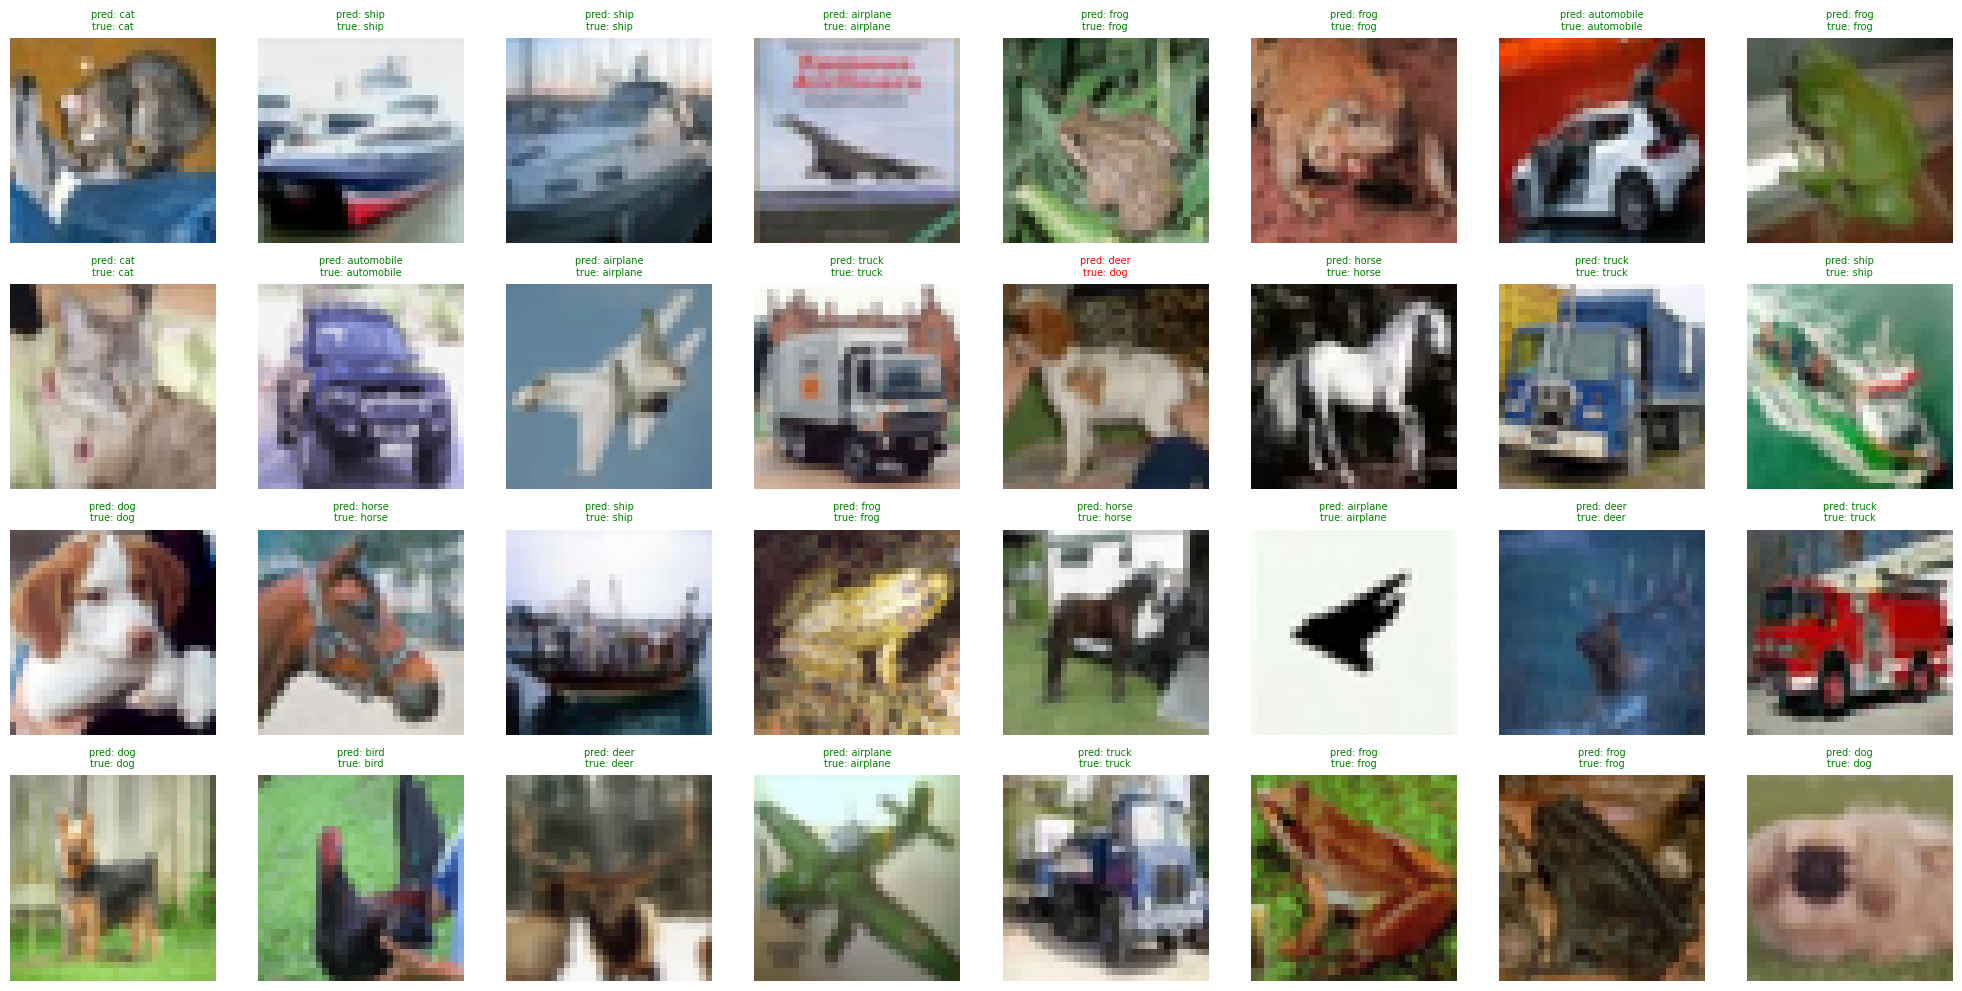

In [75]:
import matplotlib.pyplot as plt
import numpy as np

CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits, _ = model(images)
    probs = F.softmax(logits, dim=-1)
    preds = logits.argmax(dim=1)

# unnormalize for display
mean = torch.tensor([0.49139968, 0.48215827, 0.44653124])
std  = torch.tensor([0.24703233, 0.24348505, 0.26158768])

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu() * std[:, None, None] + mean[:, None, None]
    img = img.permute(1, 2, 0).clamp(0, 1)
    ax.imshow(img)
    correct = preds[i] == labels[i]
    color = 'green' if correct else 'red'
    ax.set_title(
        f"pred: {CIFAR_CLASSES[preds[i]]}\ntrue: {CIFAR_CLASSES[labels[i]]}",
        fontsize=7, color=color
    )
    ax.axis('off')
plt.tight_layout()
plt.savefig('inference_grid.png', dpi=150)
plt.show()

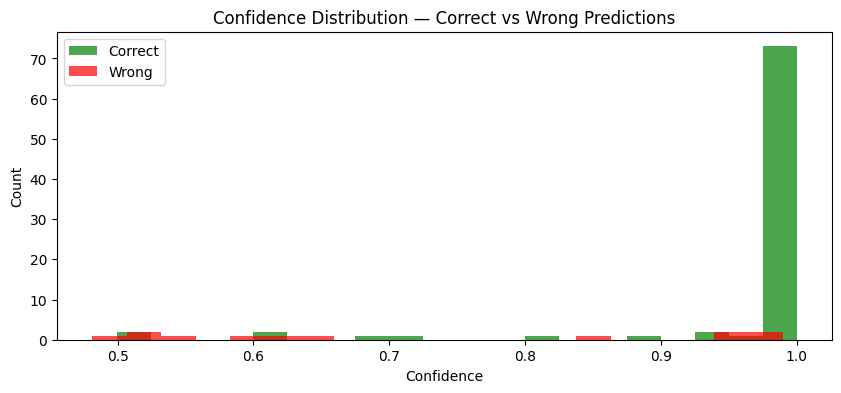

In [76]:
correct_confs = probs.max(dim=1).values[preds == labels].cpu().numpy()
wrong_confs   = probs.max(dim=1).values[preds != labels].cpu().numpy()

plt.figure(figsize=(10, 4))
plt.hist(correct_confs, bins=20, alpha=0.7, label='Correct', color='green')
plt.hist(wrong_confs,   bins=20, alpha=0.7, label='Wrong',   color='red')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.title('Confidence Distribution — Correct vs Wrong Predictions')
plt.legend()
plt.savefig('confidence_dist.png', dpi=150)
plt.show()

airplane    : 89.2%
automobile  : 94.8%
bird        : 81.4%
cat         : 74.2%
deer        : 93.6%
dog         : 91.8%
frog        : 96.8%
horse       : 96.5%
ship        : 96.8%
truck       : 96.7%


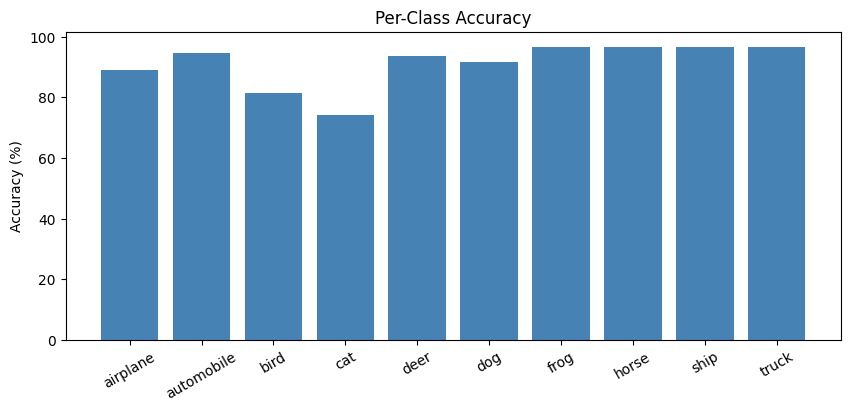

In [77]:
class_correct = torch.zeros(10)
class_total   = torch.zeros(10)

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits, _ = model(images)
        preds = logits.argmax(dim=1)
        for c in range(10):
            mask = labels == c
            class_correct[c] += (preds[mask] == labels[mask]).sum().item()
            class_total[c]   += mask.sum().item()

per_class_acc = 100 * class_correct / class_total
for c, acc in enumerate(per_class_acc):
    print(f"{CIFAR_CLASSES[c]:12s}: {acc:.1f}%")

plt.figure(figsize=(10, 4))
plt.bar(CIFAR_CLASSES, per_class_acc.numpy(), color='steelblue')
plt.ylabel('Accuracy (%)')
plt.title('Per-Class Accuracy')
plt.xticks(rotation=30)
plt.savefig('per_class_acc.png', dpi=150)
plt.show()